# Huawei Random Forest Baseline

基于论文中的特征处理思路，对 Huawei 原始流级 CSV 提取基础统计特征，并执行同一套特征消除后训练 Random Forest。

流程包括：
- 从 `arrive_time`、`direction`、`pkt_len` 构建流级候选特征
- 删除 `min_time`、`max_time`
- 删除方向计数特征，仅保留总包数
- 删除与 `total_payload` 高度冗余的 `total_length`
- 对保留特征统一做 Min-Max Scaling
- 使用 train/val/test = 0.70/0.15/0.15 训练和评估

说明：当前 Huawei CSV 没有单独的 payload 列，因此 `total_payload_bytes` 使用 `pkt_len` 累加作为代理，这会让它与 `total_length_bytes` 在本数据上完全重合。

In [ ]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
from IPython.display import display

if (Path.cwd() / "training").exists():
    sys.path.append(str(Path.cwd() / "training"))
elif Path.cwd().name == "training":
    sys.path.append(str(Path.cwd()))

from training.ml_baselines import (
    build_flow_feature_table,
    compute_feature_analysis,
    evaluate_model,
    paper_feature_elimination,
    plot_confusion,
    plot_correlation_matrix,
    plot_feature_importance,
    resolve_repo_root,
    select_best_model,
    split_scale_dataset,
)

CONFIG = {
    "seed": 42,
    "model_key": "random_forest",
    "model_name": "Random Forest",
    "train_ratio": 0.70,
    "val_ratio": 0.15,
    "test_ratio": 0.15,
    "model_save_path": "./models/huawei_random_forest_paper_features.joblib",
}

CONFIG

{'seed': 42,
 'model_key': 'random_forest',
 'model_name': 'Random Forest',
 'train_ratio': 0.7,
 'val_ratio': 0.15,
 'test_ratio': 0.15,
 'model_save_path': 'models/huawei_random_forest_paper_features.joblib'}

Feature table shape: (3200, 12)
Class distribution: {'cloud_game': 400, 'live': 400, 'meeting': 400, 'message': 400, 'openlive': 400, 'phone_game': 400, 'short_video': 400, 'video': 400}
Candidate features: ['min_time_ms', 'max_time_ms', 'flow_duration_ms', 'num_packets', 'avg_packet_size_bytes', 'total_length_bytes', 'total_payload_bytes', 'uplink_pkt_count', 'downlink_pkt_count']
Selected features: ['flow_duration_ms', 'num_packets', 'avg_packet_size_bytes', 'total_payload_bytes']
Split sizes: {'train': 2239, 'val': 481, 'test': 480}


,feature,rf_importance,f_stat,p_value,top_corr_feature,top_abs_corr
0,downlink_pkt_count,0.197641,197.207358,1.188043e-243,num_packets,0.664271
1,avg_packet_size_bytes,0.129024,121.967940,3.236680e-159,total_length_bytes,0.458006
2,uplink_pkt_count,0.119920,185.709373,2.179889e-231,total_length_bytes,0.984705
3,total_length_bytes,0.117884,188.828697,9.774459e-235,total_payload_bytes,1.000000
4,total_payload_bytes,0.117334,188.828697,9.774459e-235,total_length_bytes,1.000000
5,max_time_ms,0.111310,220.806290,3.624072e-268,flow_duration_ms,1.000000
6,flow_duration_ms,0.110051,220.858005,3.209274e-268,max_time_ms,1.000000
7,num_packets,0.096227,186.030286,9.845097e-232,uplink_pkt_count,0.983031
8,min_time_ms,0.000608,5.034073,1.083736e-05,flow_duration_ms,0.034720


,feature,action,reason
0,min_time_ms,drop,Paper rule: remove explicit timestamps because...
1,max_time_ms,drop,Paper rule: remove explicit timestamps because...
2,flow_duration_ms,keep,Retained by the paper-inspired elimination pol...
3,num_packets,keep,Retained by the paper-inspired elimination pol...
4,avg_packet_size_bytes,keep,Retained by the paper-inspired elimination pol...
5,total_length_bytes,drop,Paper correlation rule: redundant with total_p...
6,total_payload_bytes,keep,Retained by the paper-inspired elimination pol...
7,uplink_pkt_count,drop,Paper rule: remove direction counts and keep n...
8,downlink_pkt_count,drop,Paper rule: remove direction counts and keep n...


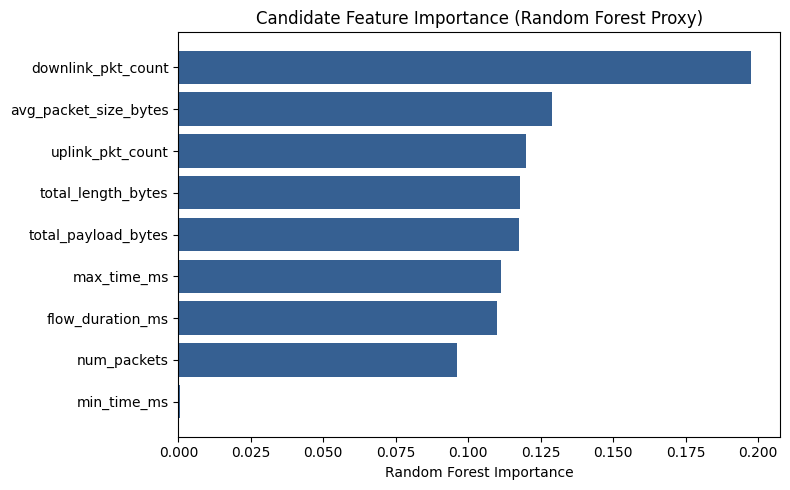

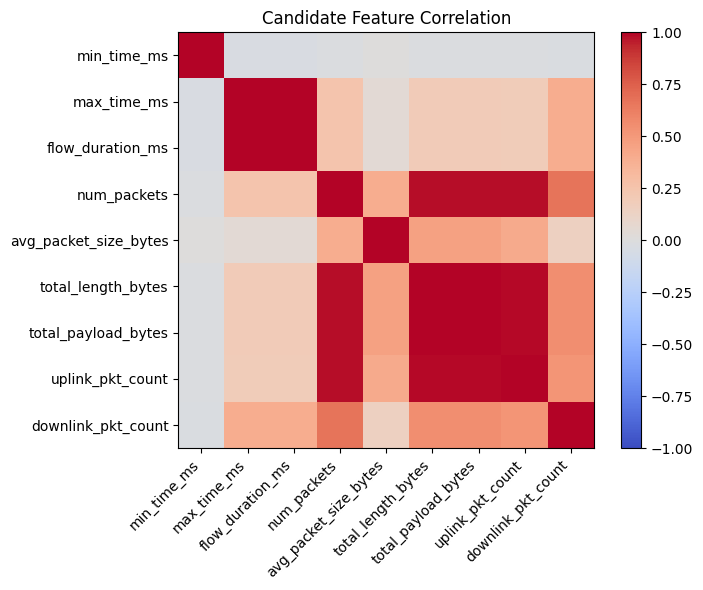

In [2]:
feature_df, candidate_features = build_flow_feature_table()
analysis_df = compute_feature_analysis(feature_df, candidate_features, seed=CONFIG["seed"])
filtered_df, elimination_df, selected_features = paper_feature_elimination(feature_df)
splits = split_scale_dataset(
    filtered_df,
    feature_names=selected_features,
    seed=CONFIG["seed"],
    train_ratio=CONFIG["train_ratio"],
    val_ratio=CONFIG["val_ratio"],
    test_ratio=CONFIG["test_ratio"],
)

print("Feature table shape:", feature_df.shape)
print("Class distribution:", filtered_df["label"].value_counts().sort_index().to_dict())
print("Candidate features:", candidate_features)
print("Selected features:", selected_features)
print("Split sizes:", {"train": splits["train_size"], "val": splits["val_size"], "test": splits["test_size"]})
display(analysis_df)
display(elimination_df)
plot_feature_importance(analysis_df, title="Candidate Feature Importance (Random Forest Proxy)")
plot_correlation_matrix(feature_df, candidate_features, title="Candidate Feature Correlation")
plt.show()

In [3]:
search_results_df, best_params, best_model = select_best_model(
    model_key=CONFIG["model_key"],
    X_train=splits["X_train"],
    y_train=splits["y_train"],
    X_val=splits["X_val"],
    y_val=splits["y_val"],
    num_classes=len(splits["class_names"]),
    seed=CONFIG["seed"],
)

display(search_results_df)
print("Best params:", best_params)

,trial,params,val_macro_f1,val_accuracy
0,3,"{""class_weight"": ""balanced_subsample"", ""max_de...",0.737351,0.735967
1,1,"{""class_weight"": ""balanced_subsample"", ""max_de...",0.733239,0.731809
2,2,"{""class_weight"": ""balanced_subsample"", ""max_de...",0.727540,0.725572
3,4,"{""class_weight"": ""balanced_subsample"", ""max_de...",0.715158,0.713098


Best params: {'n_estimators': 400, 'max_depth': 18, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'class_weight': 'balanced_subsample'}


Validation accuracy: 0.7360 | Validation macro F1: 0.7374
Test accuracy: 0.7458 | Test macro F1: 0.7458 | Test balanced accuracy: 0.7458

Test Classification Report:

              precision    recall  f1-score   support

  cloud_game     0.8000    0.8667    0.8320        60
        live     0.5690    0.5500    0.5593        60
     meeting     0.8367    0.6833    0.7523        60
     message     0.8667    0.8667    0.8667        60
    openlive     0.6522    0.7500    0.6977        60
  phone_game     0.6949    0.6833    0.6891        60
 short_video     0.8571    0.8000    0.8276        60
       video     0.7188    0.7667    0.7419        60

    accuracy                         0.7458       480
   macro avg     0.7494    0.7458    0.7458       480
weighted avg     0.7494    0.7458    0.7458       480



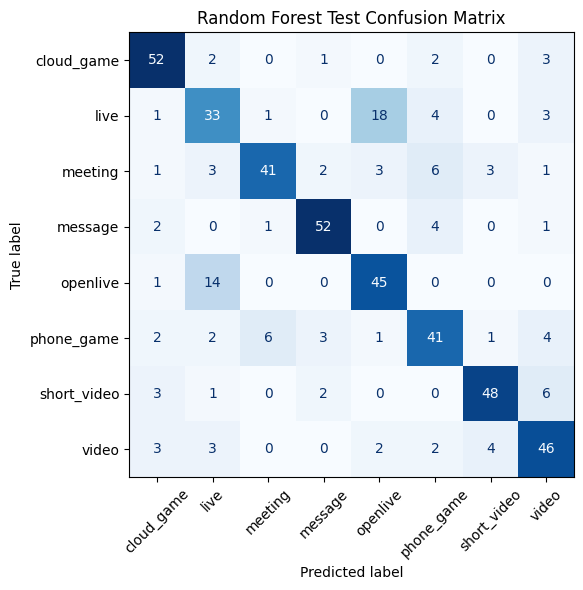

Saved model bundle to: /home/ronghanj/dev/network-traffic-classification/models/huawei_random_forest_paper_features.joblib


In [4]:
val_metrics = evaluate_model(best_model, splits["X_val"], splits["y_val"], splits["class_names"])
test_metrics = evaluate_model(best_model, splits["X_test"], splits["y_test"], splits["class_names"])

print(f"Validation accuracy: {val_metrics['accuracy']:.4f} | Validation macro F1: {val_metrics['macro_f1']:.4f}")
print(f"Test accuracy: {test_metrics['accuracy']:.4f} | Test macro F1: {test_metrics['macro_f1']:.4f} | Test balanced accuracy: {test_metrics['balanced_accuracy']:.4f}")
print("\nTest Classification Report:\n")
print(test_metrics["report"])
plot_confusion(test_metrics["confusion_matrix"], splits["class_names"], title=f"{CONFIG['model_name']} Test Confusion Matrix")
plt.show()

repo_root = resolve_repo_root()
model_path = repo_root / CONFIG["model_save_path"]
model_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(
    {
        "model": best_model,
        "scaler": splits["scaler"],
        "feature_names": splits["feature_names"],
        "label_to_id": splits["label_to_id"],
        "config": CONFIG,
        "best_params": best_params,
        "test_metrics": {
            "accuracy": test_metrics["accuracy"],
            "macro_f1": test_metrics["macro_f1"],
            "balanced_accuracy": test_metrics["balanced_accuracy"],
        },
    },
    model_path,
)
print("Saved model bundle to:", model_path.resolve())